# Twitter Entity Sentiment Analysis — EDA, Classical ML & BERT


### Workflow

1. Data loading and quality checks  
2. Detailed exploratory data analysis  
3. Text and metadata analysis  
4. Text preprocessing  
5. TF-IDF + entity features  
6. Classical machine-learning benchmark  
7. Hyperparameter tuning  
8. Confusion matrices and error analysis  
9. Optional BERT fine-tuning  
10. Final model comparison and conclusions



## 1. Imports and configuration

In [1]:
import os
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TRAIN_PATH = "/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv"
VALID_PATH = "/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv"

RUN_TUNING = False      # Set True to run GridSearchCV
RUN_BERT = False        # Set True on a Kaggle GPU session
BERT_TRAIN_SAMPLE = 30000

## 2. Load the data correctly

In [2]:
columns = ["TweetID", "Entity", "Sentiment", "Text"]

train_df = pd.read_csv(
    TRAIN_PATH,
    header=None,
    names=columns,
)

valid_df = pd.read_csv(
    VALID_PATH,
    header=None,
    names=columns,
)

print("Training shape :", train_df.shape)
print("Validation shape:", valid_df.shape)

display(train_df.head())
display(valid_df.head())

Training shape : (74682, 4)
Validation shape: (1000, 4)


,TweetID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


,TweetID,Entity,Sentiment,Text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


## 3. Initial data audit

In [3]:
def audit_dataframe(df, name):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print("Shape:", df.shape)
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nMissing percentage:")
    print((df.isna().mean() * 100).round(3))
    print("\nExact duplicate rows:", df.duplicated().sum())
    print("Unique entities:", df["Entity"].nunique())
    print("Unique sentiment labels:", df["Sentiment"].unique())

audit_dataframe(train_df, "TRAIN")
audit_dataframe(valid_df, "VALIDATION")


TRAIN
Shape: (74682, 4)

Dtypes:
TweetID       int64
Entity       object
Sentiment    object
Text         object
dtype: object

Missing values:
TweetID        0
Entity         0
Sentiment      0
Text         686
dtype: int64

Missing percentage:
TweetID      0.000
Entity       0.000
Sentiment    0.000
Text         0.919
dtype: float64

Exact duplicate rows: 2700
Unique entities: 32
Unique sentiment labels: ['Positive' 'Neutral' 'Negative' 'Irrelevant']

VALIDATION
Shape: (1000, 4)

Dtypes:
TweetID       int64
Entity       object
Sentiment    object
Text         object
dtype: object

Missing values:
TweetID      0
Entity       0
Sentiment    0
Text         0
dtype: int64

Missing percentage:
TweetID      0.0
Entity       0.0
Sentiment    0.0
Text         0.0
dtype: float64

Exact duplicate rows: 0
Unique entities: 32
Unique sentiment labels: ['Irrelevant' 'Neutral' 'Negative' 'Positive']


## 4. Cleaning

In [4]:
def basic_clean_dataframe(df):
    df = df.copy()

    # Remove rows without text or labels.
    df = df.dropna(subset=["Text", "Sentiment", "Entity"])

    # Remove exact duplicated rows.
    df = df.drop_duplicates()

    # Normalize strings.
    df["Text"] = df["Text"].astype(str).str.strip()
    df["Entity"] = df["Entity"].astype(str).str.strip()
    df["Sentiment"] = df["Sentiment"].astype(str).str.strip()

    # Remove empty text after stripping.
    df = df[df["Text"].str.len() > 0].reset_index(drop=True)

    return df

train_df = basic_clean_dataframe(train_df)
valid_df = basic_clean_dataframe(valid_df)

print("Clean training shape :", train_df.shape)
print("Clean validation shape:", valid_df.shape)

Clean training shape : (71484, 4)
Clean validation shape: (1000, 4)


## 5. Check train/validation overlap

In [5]:
train_texts = set(train_df["Text"])
valid_texts = set(valid_df["Text"])

overlap = train_texts.intersection(valid_texts)

print("Exact text overlap between train and validation:", len(overlap))
print(
    "Overlap as % of validation unique texts:",
    round(100 * len(overlap) / max(1, len(valid_texts)), 2),
    "%"
)

Exact text overlap between train and validation: 516
Overlap as % of validation unique texts: 51.65 %


## 6. Exploratory Data Analysis

We first examine class balance, entities, text length, and simple Twitter-specific features before training any model.

### 6.1 Sentiment distribution

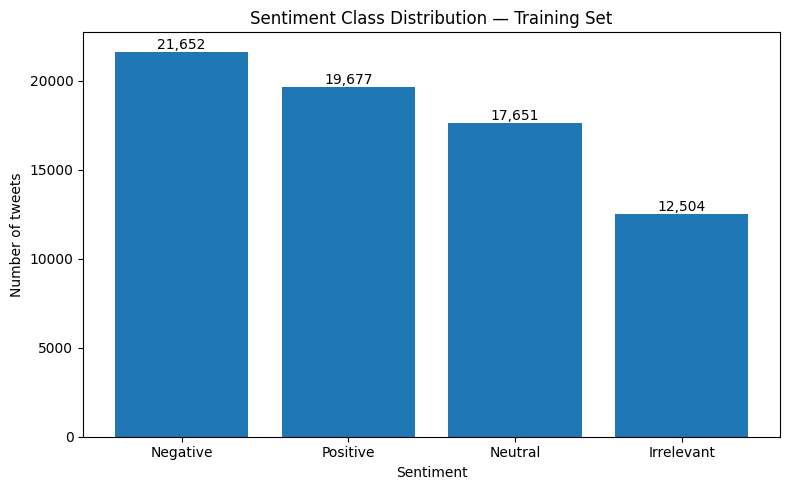

,count,percentage
Sentiment,,
Negative,21652,30.29
Positive,19677,27.53
Neutral,17651,24.69
Irrelevant,12504,17.49


In [6]:
sentiment_counts = train_df["Sentiment"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(sentiment_counts.index, sentiment_counts.values)
ax.set_title("Sentiment Class Distribution — Training Set")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of tweets")

for i, value in enumerate(sentiment_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "count": sentiment_counts,
        "percentage": (sentiment_counts / sentiment_counts.sum() * 100).round(2)
    })
)

### 6.2 Entity distribution

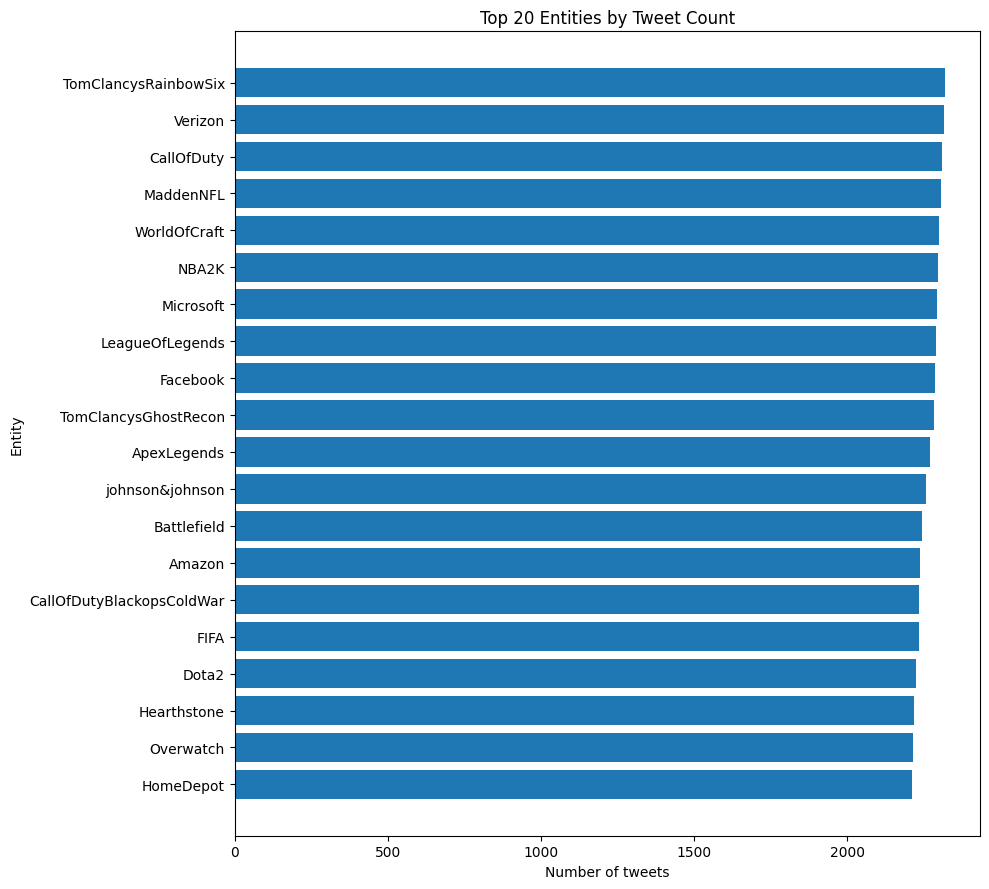

Number of entities: 32


count      32.00000
mean     2233.87500
std        54.42826
min      2139.00000
25%      2191.00000
50%      2229.50000
75%      2288.00000
max      2318.00000
Name: count, dtype: float64

In [7]:
entity_counts = train_df["Entity"].value_counts()

fig, ax = plt.subplots(figsize=(10, 9))
top_entities = entity_counts.head(20).sort_values()
ax.barh(top_entities.index, top_entities.values)
ax.set_title("Top 20 Entities by Tweet Count")
ax.set_xlabel("Number of tweets")
ax.set_ylabel("Entity")
plt.tight_layout()
plt.show()

print("Number of entities:", train_df["Entity"].nunique())
display(entity_counts.describe())

### 6.3 Sentiment composition by entity

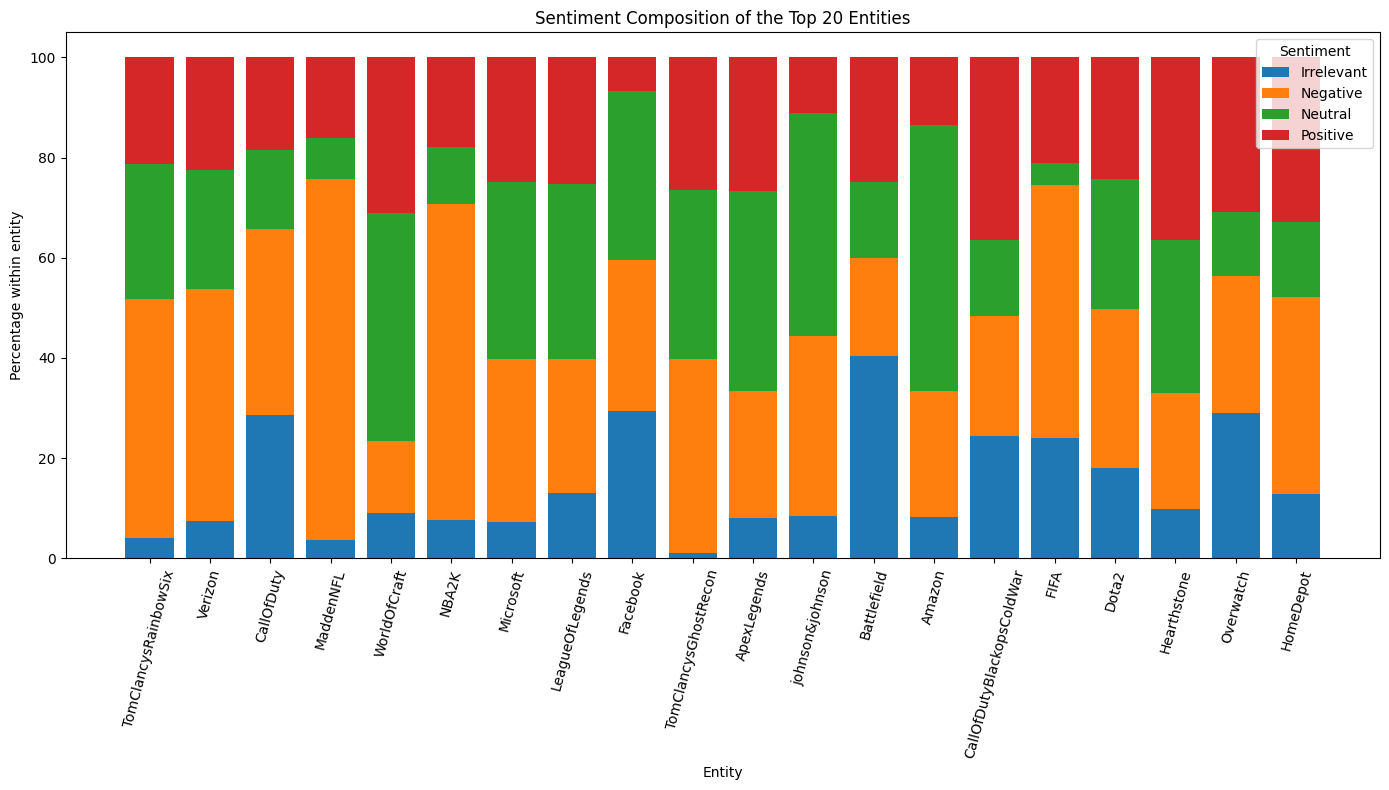

In [8]:
entity_sentiment = pd.crosstab(
    train_df["Entity"],
    train_df["Sentiment"],
    normalize="index"
) * 100

# Show the 20 largest entities to keep the plot readable.
top20 = entity_counts.head(20).index
plot_df = entity_sentiment.loc[top20]

fig, ax = plt.subplots(figsize=(14, 8))
bottom = np.zeros(len(plot_df))

for sentiment in plot_df.columns:
    values = plot_df[sentiment].values
    ax.bar(plot_df.index, values, bottom=bottom, label=sentiment)
    bottom += values

ax.set_title("Sentiment Composition of the Top 20 Entities")
ax.set_ylabel("Percentage within entity")
ax.set_xlabel("Entity")
ax.tick_params(axis="x", rotation=75)
ax.legend(title="Sentiment")
plt.tight_layout()
plt.show()

### 6.4 Which entities are most positive / negative / neutral / irrelevant?

In [9]:
for sentiment in entity_sentiment.columns:
    print(f"\nTop entities by percentage of {sentiment}:")
    display(
        entity_sentiment[sentiment]
        .sort_values(ascending=False)
        .head(10)
        .to_frame("percentage")
        .round(2)
    )


Top entities by percentage of Irrelevant:


,percentage
Entity,
PlayerUnknownsBattlegrounds(PUBG),40.35
Battlefield,40.34
Fortnite,37.62
GrandTheftAuto(GTA),33.82
Xbox(Xseries),31.46
Facebook,29.34
Overwatch,29.11
CallOfDuty,28.58
CS-GO,28.25



Top entities by percentage of Negative:


,percentage
Entity,
MaddenNFL,71.92
NBA2K,63.05
FIFA,50.36
TomClancysRainbowSix,47.80
Verizon,46.18
HomeDepot,39.29
TomClancysGhostRecon,38.75
CallOfDuty,37.16
johnson&johnson,35.84



Top entities by percentage of Neutral:


,percentage
Entity,
Amazon,53.11
WorldOfCraft,45.50
johnson&johnson,44.48
ApexLegends,40.10
Nvidia,38.61
RedDeadRedemption(RDR),35.92
Google,35.69
Microsoft,35.30
LeagueOfLegends,34.88



Top entities by percentage of Positive:


,percentage
Entity,
AssassinsCreed,64.10
Borderlands,44.06
Cyberpunk2077,41.52
RedDeadRedemption(RDR),41.12
PlayStation5(PS5),40.78
CallOfDutyBlackopsColdWar,36.49
Hearthstone,36.36
Nvidia,34.60
Xbox(Xseries),33.93


### 6.5 Text-length analysis

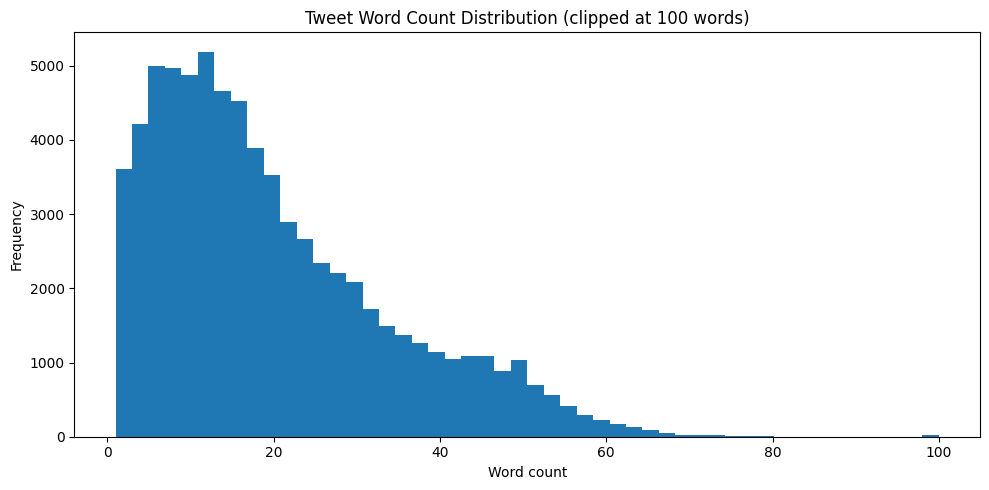

,char_count,word_count,url_count,mention_count,hashtag_count,exclamation_count,question_count
Sentiment,,,,,,,
Irrelevant,112.27,19.90,0.02,0.22,0.0,0.42,0.17
Negative,113.60,20.48,0.01,0.36,0.0,0.25,0.30
Neutral,119.79,20.45,0.06,0.21,0.0,0.42,0.15
Positive,98.37,17.66,0.01,0.18,0.0,0.54,0.09


In [10]:
def add_text_features(df):
    df = df.copy()

    df["char_count"] = df["Text"].str.len()
    df["word_count"] = df["Text"].str.split().str.len()
    df["url_count"] = df["Text"].str.count(r"https?://\S+|www\.\S+")
    df["mention_count"] = df["Text"].str.count(r"@\w+")
    df["hashtag_count"] = df["Text"].str.count(r"#\w+")
    df["exclamation_count"] = df["Text"].str.count("!")
    df["question_count"] = df["Text"].str.count(r"\?")

    return df

train_df = add_text_features(train_df)
valid_df = add_text_features(valid_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_df["word_count"].clip(upper=100), bins=50)
ax.set_title("Tweet Word Count Distribution (clipped at 100 words)")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

display(
    train_df.groupby("Sentiment")[
        ["char_count", "word_count", "url_count", "mention_count",
         "hashtag_count", "exclamation_count", "question_count"]
    ].mean().round(2)
)

### 6.6 Text length by sentiment

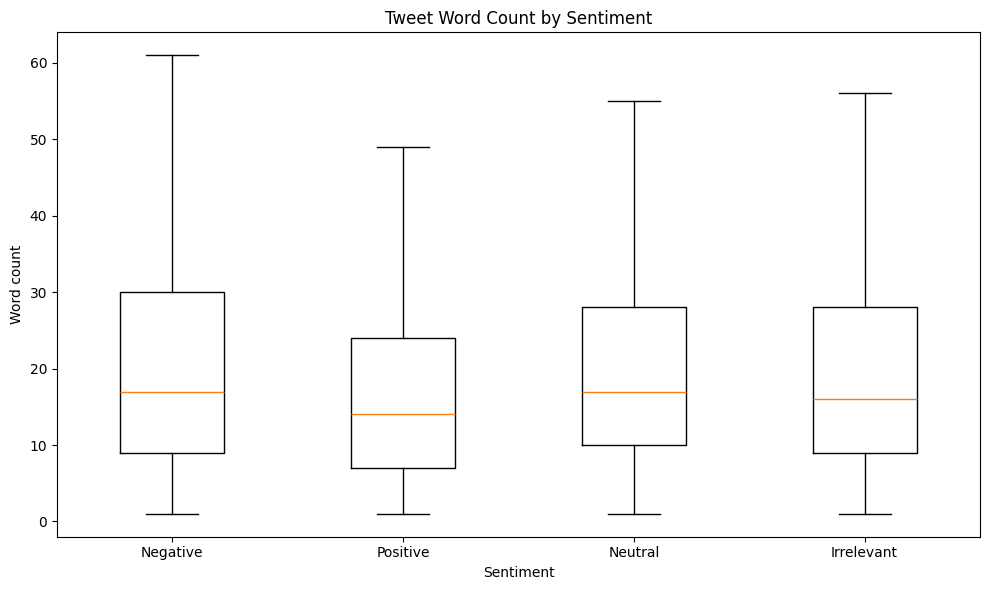

In [11]:
sentiments = train_df["Sentiment"].value_counts().index.tolist()

data_to_plot = [
    train_df.loc[train_df["Sentiment"] == sentiment, "word_count"].clip(upper=80).values
    for sentiment in sentiments
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_to_plot, labels=sentiments, showfliers=False)
ax.set_title("Tweet Word Count by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Word count")
plt.tight_layout()
plt.show()

### 6.7 Most frequent words and bigrams by sentiment

In [12]:
def top_ngrams(texts, ngram_range=(1, 1), top_n=15):
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=ngram_range,
        min_df=3,
        max_features=20000,
    )

    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.asarray(vectorizer.get_feature_names_out())

    order = counts.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "term": terms[order],
        "count": counts[order]
    })

for sentiment in sorted(train_df["Sentiment"].unique()):
    subset = train_df.loc[train_df["Sentiment"] == sentiment, "Text"]

    print(f"\nTop words — {sentiment}")
    display(top_ngrams(subset, (1, 1), 15))

    print(f"Top bigrams — {sentiment}")
    display(top_ngrams(subset, (2, 2), 15))


Top words — Irrelevant


,term,count
0,com,1821
1,player,1127
2,just,1116
3,ban,990
4,like,987
5,game,802
6,people,761
7,love,669
8,good,657
9,unk,620


Top bigrams — Irrelevant


,term,count
0,com player,479
1,player ban,475
2,bf4db com,461
3,twitter com,444
4,details bf4db,394
5,pic twitter,386
6,occurred details,326
7,battlefield player,313
8,italy italy,294
9,ban battlefield,268



Top words — Negative


...

,term,count
0,johnson johnson,744
1,twitter com,657
2,pic twitter,616
3,red dead,564
4,twitch tv,527
5,com 2020,416
6,dead redemption,416
7,xbox series,290
8,baby powder,260
9,bit ly,252



Top words — Positive


,term,count
0,game,2262
1,com,1846
2,love,1717
3,just,1668
4,good,1555
5,like,1327
6,really,1268
7,pic,1257
8,new,1190
9,best,1099


Top bigrams — Positive


,term,count
0,twitter com,1037
1,pic twitter,1013
2,red dead,581
3,dead redemption,484
4,assassin creed,338
5,home depot,327
6,twitch tv,327
7,assassins creed,221
8,xbox series,218
9,black ops,200


## 7. Text preprocessing

For sentiment analysis, preprocessing should be conservative. Negations such as **not**, **never**, and **no** can be highly informative, so we do not blindly remove all stop words.

We normalize URLs, mentions, whitespace, and casing while keeping the overall sentence structure.

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["CleanText"] = train_df["Text"].map(clean_text)
valid_df["CleanText"] = valid_df["Text"].map(clean_text)

display(train_df[["Text", "CleanText"]].head())

,Text,CleanText
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...


## 8. Feature engineering

We combine:

- **TF-IDF word features** from the tweet text
- **One-hot encoded entity features**

This is useful because the task is entity-level sentiment analysis, not generic tweet sentiment analysis.

In [14]:
feature_builder = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=40000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
            ),
            "CleanText",
        ),
        (
            "entity",
            OneHotEncoder(handle_unknown="ignore"),
            ["Entity"],
        ),
    ],
    remainder="drop",
)

X_train = feature_builder.fit_transform(train_df)
X_valid = feature_builder.transform(valid_df)

y_train = train_df["Sentiment"].values
y_valid = valid_df["Sentiment"].values

print("Training feature matrix :", X_train.shape)
print("Validation feature matrix:", X_valid.shape)

Training feature matrix : (71484, 40032)
Validation feature matrix: (1000, 40032)


## 9. Classical machine-learning benchmark

We compare several algorithms under the **same feature representation and validation set**.

Metrics:

- Accuracy
- Macro F1
- Weighted F1
- Macro precision
- Macro recall
- Training time

Macro F1 is especially useful when class frequencies are not perfectly balanced.

In [15]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Complement Naive Bayes": ComplementNB(alpha=0.5),
    "Logistic Regression": LogisticRegression(
        C=2.0,
        max_iter=1500,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE,
    ),
    "SGD Classifier": SGDClassifier(
        loss="modified_huber",
        max_iter=1500,
        random_state=RANDOM_STATE,
    ),
    "Ridge Classifier": RidgeClassifier(
        alpha=1.0,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=60,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
}

results = []
predictions = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining: {name}")

    start = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    pred = model.predict(X_valid)

    predictions[name] = pred
    trained_models[name] = model

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Macro F1": f1_score(y_valid, pred, average="macro"),
        "Weighted F1": f1_score(y_valid, pred, average="weighted"),
        "Macro Precision": precision_score(
            y_valid, pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_valid, pred, average="macro", zero_division=0
        ),
        "Train Time (s)": elapsed,
    }

    results.append(result)

results_df = (
    pd.DataFrame(results)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "Macro Precision": "{:.4f}",
    "Macro Recall": "{:.4f}",
    "Train Time (s)": "{:.2f}",
}))


Training: Dummy Baseline

Training: Complement Naive Bayes

Training: Logistic Regression

Training: Linear SVM

Training: SGD Classifier

Training: Ridge Classifier

Training: Decision Tree


,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Train Time (s)
0,Linear SVM,0.9780,0.9788,0.9780,0.9798,0.9779,8.38
1,Ridge Classifier,0.9760,0.9761,0.9761,0.9781,0.9745,3.10
2,Logistic Regression,0.9690,0.9687,0.9690,0.9705,0.9670,14.23
3,SGD Classifier,0.9560,0.9551,0.9559,0.9574,0.9533,0.92
4,Complement Naive Bayes,0.8810,0.8802,0.8808,0.8839,0.8783,0.14
5,Decision Tree,0.7890,0.7884,0.7906,0.8099,0.7803,27.23
6,Dummy Baseline,0.2660,0.1051,0.1118,0.0665,0.2500,0.03


### 9.1 Model comparison plot

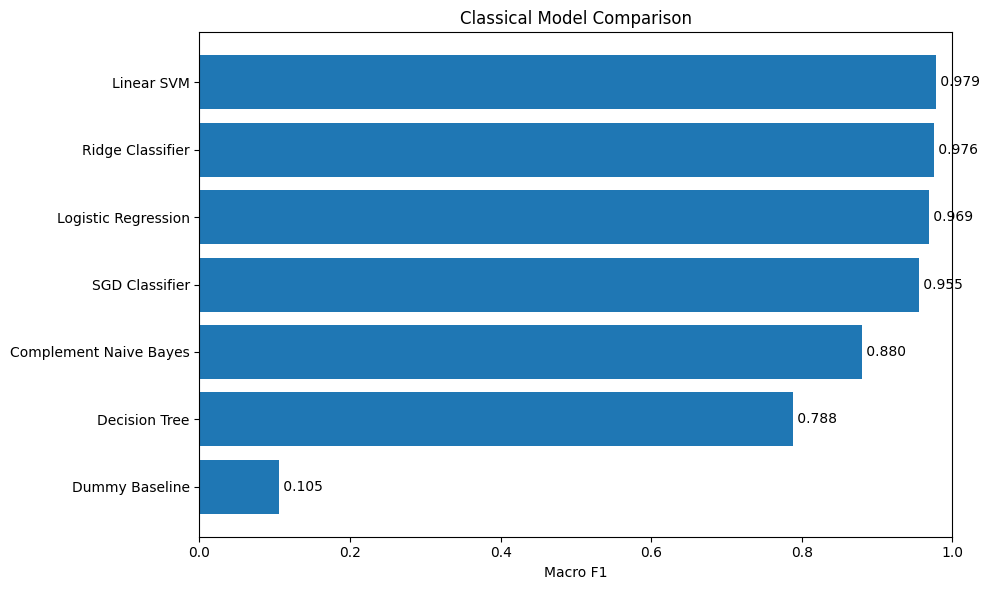

In [16]:
plot_df = results_df.sort_values("Macro F1")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["Model"], plot_df["Macro F1"])
ax.set_title("Classical Model Comparison")
ax.set_xlabel("Macro F1")
ax.set_xlim(0, 1)

for i, value in enumerate(plot_df["Macro F1"]):
    ax.text(value, i, f" {value:.3f}", va="center")

plt.tight_layout()
plt.show()

### 9.2 Best classical model report

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best classical model:", best_model_name)
print()
print(classification_report(y_valid, best_pred))

Best classical model: Linear SVM

              precision    recall  f1-score   support

  Irrelevant       0.99      0.98      0.99       172
    Negative       0.98      0.98      0.98       266
     Neutral       0.98      0.97      0.98       285
    Positive       0.96      0.99      0.97       277

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



### 9.3 Confusion matrix

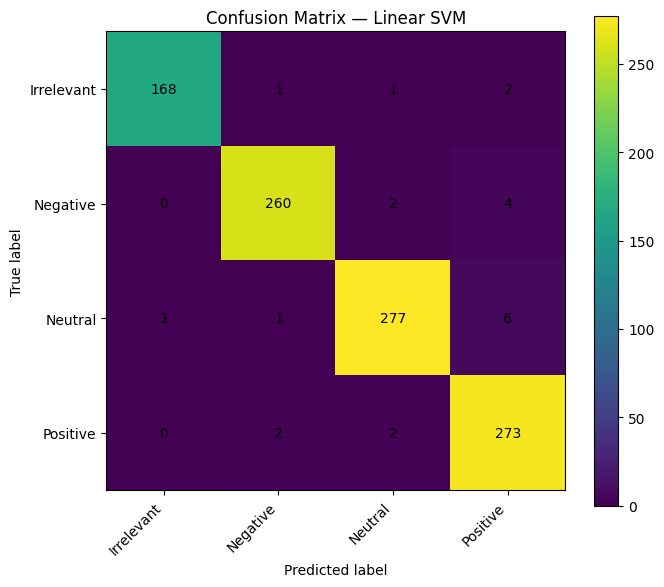

In [18]:
labels = sorted(train_df["Sentiment"].unique())
cm = confusion_matrix(y_valid, best_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix — {best_model_name}")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. Optional hyperparameter tuning

The benchmark above is intentionally fast.  
Set `RUN_TUNING = True` if you want to perform a more expensive grid search.

Here we tune Logistic Regression because it is typically a strong and interpretable baseline for sparse TF-IDF features.

In [19]:
if RUN_TUNING:
    param_grid = {
        "C": [0.5, 1.0, 2.0, 4.0],
        "class_weight": [None, "balanced"],
    }

    grid = GridSearchCV(
        estimator=LogisticRegression(
            max_iter=1500,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1,
    )

    grid.fit(X_train, y_train)

    tuned_pred = grid.best_estimator_.predict(X_valid)

    print("Best parameters:", grid.best_params_)
    print("Best CV macro F1:", grid.best_score_)
    print("Validation accuracy:", accuracy_score(y_valid, tuned_pred))
    print("Validation macro F1:", f1_score(y_valid, tuned_pred, average="macro"))
    print()
    print(classification_report(y_valid, tuned_pred))
else:
    print("Skipping tuning. Set RUN_TUNING = True to run it.")

Skipping tuning. Set RUN_TUNING = True to run it.


## 11. Error analysis

A high-level score is not enough. We inspect where the best classical model fails and which class pairs are most frequently confused.

In [20]:
error_df = valid_df[["TweetID", "Entity", "Sentiment", "Text", "word_count"]].copy()
error_df["Predicted"] = best_pred
error_df["Correct"] = error_df["Sentiment"] == error_df["Predicted"]

print("Validation errors:", (~error_df["Correct"]).sum())
print("Validation error rate:", round((~error_df["Correct"]).mean() * 100, 2), "%")

display(
    error_df.loc[~error_df["Correct"]]
    .sample(min(20, (~error_df["Correct"]).sum()), random_state=RANDOM_STATE)
)

Validation errors: 22
Validation error rate: 2.2 %


,TweetID,Entity,Sentiment,Text,word_count,Predicted,Correct
72,9608,PlayStation5(PS5),Negative,God when 🥺,3,Positive,False
545,9666,PlayStation5(PS5),Neutral,My main reason for wanting the #PS5 is because...,47,Positive,False
390,5149,GrandTheftAuto(GTA),Neutral,Mori😻😻😻😻,1,Irrelevant,False
91,3286,Facebook,Negative,Leaked memo excoriates #Facebook’s ‘slapdash a...,14,Neutral,False
697,4276,CS-GO,Neutral,Aiiight 💪,2,Positive,False
213,115,Amazon,Negative,Plague of Corruption is #1 on Amazon and # 3 o...,17,Positive,False
924,452,ApexLegends,Positive,Woohoooo Next #ApexLegends comic is out !!! Th...,15,Neutral,False
476,6894,johnson&johnson,Negative,EXTRAORDINARY: Podcast about Deanna Berg's fig...,29,Neutral,False
98,3526,Facebook,Neutral,Our #HISAPerth #OBIawards ceremony is taking p...,40,Positive,False
109,10585,RedDeadRedemption(RDR),Neutral,RED DEAD REDEMPTION 2 \n#RDOnline #RDR2\n#Dail...,10,Positive,False


### 11.1 Most common confusion pairs

In [21]:
confusions = (
    error_df.loc[~error_df["Correct"]]
    .groupby(["Sentiment", "Predicted"])
    .size()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
)

display(confusions.head(15))

,Sentiment,Predicted,count
0,Neutral,Positive,6
1,Negative,Positive,4
2,Positive,Neutral,2
3,Positive,Negative,2
4,Negative,Neutral,2
5,Irrelevant,Positive,2
6,Irrelevant,Neutral,1
7,Irrelevant,Negative,1
8,Neutral,Irrelevant,1
9,Neutral,Negative,1


### 11.2 Accuracy by entity

In [22]:
entity_accuracy = (
    error_df.assign(correct_int=error_df["Correct"].astype(int))
    .groupby("Entity")
    .agg(
        accuracy=("correct_int", "mean"),
        samples=("correct_int", "size"),
    )
    .sort_values("accuracy")
)

print("Entities with the lowest validation accuracy:")
display(entity_accuracy.head(15))

print("\nEntities with the highest validation accuracy:")
display(entity_accuracy.tail(15))

Entities with the lowest validation accuracy:


,accuracy,samples
Entity,,
Facebook,0.939394,33
PlayStation5(PS5),0.939394,33
GrandTheftAuto(GTA),0.942857,35
ApexLegends,0.944444,36
PlayerUnknownsBattlegrounds(PUBG),0.947368,38
RedDeadRedemption(RDR),0.950000,40
TomClancysGhostRecon,0.954545,22
Xbox(Xseries),0.961538,26
CallOfDutyBlackopsColdWar,0.962963,27



Entities with the highest validation accuracy:


,accuracy,samples
Entity,,
Google,1.0,24
Dota2,1.0,27
Cyberpunk2077,1.0,30
Battlefield,1.0,26
AssassinsCreed,1.0,33
Borderlands,1.0,33
CallOfDuty,1.0,31
NBA2K,1.0,21
Nvidia,1.0,35


## 12. Optional BERT fine-tuning

The original dataset contains **four labels**:

- Positive
- Negative
- Neutral
- Irrelevant

This section keeps all four classes and fine-tunes a pretrained BERT model.


In [30]:
RUN_BERT = True
if RUN_BERT:
    import torch
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
    )

    label_encoder = LabelEncoder()
    label_encoder.fit(train_df["Sentiment"])

    bert_train = train_df.copy()
    bert_valid = valid_df.copy()

    # Optional stratified downsampling for a faster Kaggle experiment.
    if BERT_TRAIN_SAMPLE is not None and len(bert_train) > BERT_TRAIN_SAMPLE:
        sampled_parts = []
        per_class = BERT_TRAIN_SAMPLE // bert_train["Sentiment"].nunique()

        for label, group in bert_train.groupby("Sentiment"):
            sampled_parts.append(
                group.sample(
                    n=min(per_class, len(group)),
                    random_state=RANDOM_STATE,
                )
            )

        bert_train = (
            pd.concat(sampled_parts)
            .sample(frac=1, random_state=RANDOM_STATE)
            .reset_index(drop=True)
        )

    def make_bert_input(df):
        # Include entity information explicitly.
        return (
            "Entity: "
            + df["Entity"].astype(str)
            + ". Tweet: "
            + df["Text"].astype(str)
        )

    train_bert_df = pd.DataFrame({
        "text": make_bert_input(bert_train),
        "label": label_encoder.transform(bert_train["Sentiment"]),
    })

    valid_bert_df = pd.DataFrame({
        "text": make_bert_input(bert_valid),
        "label": label_encoder.transform(bert_valid["Sentiment"]),
    })

    train_ds = Dataset.from_pandas(train_bert_df, preserve_index=False)
    valid_ds = Dataset.from_pandas(valid_bert_df, preserve_index=False)

    MODEL_NAME = "bert-base-uncased"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=128,
        )

    train_ds = train_ds.map(tokenize_batch, batched=True)
    valid_ds = valid_ds.map(tokenize_batch, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_encoder.classes_),
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        pred = np.argmax(logits, axis=-1)

        return {
            "accuracy": accuracy_score(labels, pred),
            "macro_f1": f1_score(labels, pred, average="macro"),
            "weighted_f1": f1_score(labels, pred, average="weighted"),
        }

    training_args = TrainingArguments(
        output_dir="/kaggle/working/bert_sentiment",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=2,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=100,
        report_to="none",
        seed=RANDOM_STATE,
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

    trainer.train()

    bert_eval = trainer.evaluate()
    display(bert_eval)

    bert_output = trainer.predict(valid_ds)
    bert_pred_ids = np.argmax(bert_output.predictions, axis=-1)

    bert_true = label_encoder.inverse_transform(valid_bert_df["label"])
    bert_pred = label_encoder.inverse_transform(bert_pred_ids)

    print(classification_report(bert_true, bert_pred))

else:
    print(
        "BERT section is disabled. "
        "Set RUN_BERT = True and enable a Kaggle GPU to run it."
    )

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.649157,1.320194,0.744000,0.740112,0.743737
2,1.321789,1.113147,0.799000,0.798645,0.797663


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 1.1131470203399658,
 'eval_accuracy': 0.799,
 'eval_macro_f1': 0.7986445991437278,
 'eval_weighted_f1': 0.7976627665211173,
 'eval_runtime': 3.796,
 'eval_samples_per_second': 263.434,
 'eval_steps_per_second': 4.215,
 'epoch': 2.0}

              precision    recall  f1-score   support

  Irrelevant       0.81      0.79      0.80       172
    Negative       0.81      0.86      0.84       266
     Neutral       0.80      0.70      0.75       285
    Positive       0.78      0.84      0.81       277

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



## 13. BERT confusion matrix

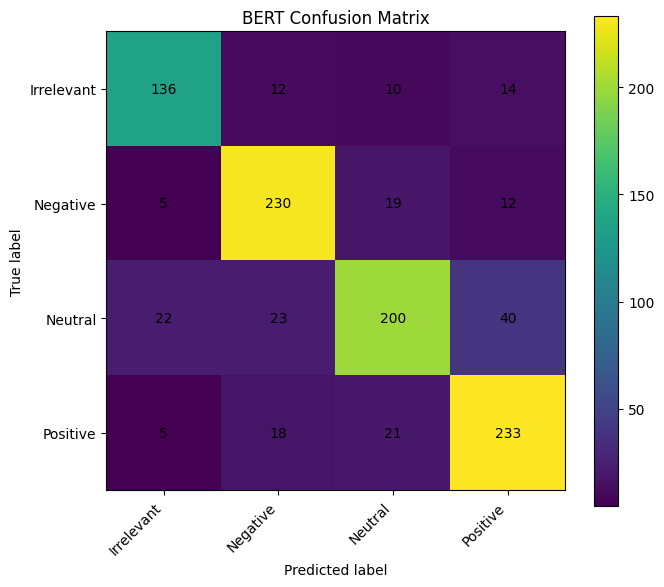

In [31]:
if RUN_BERT:
    bert_labels = list(label_encoder.classes_)
    bert_cm = confusion_matrix(
        bert_true,
        bert_pred,
        labels=bert_labels,
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(bert_cm)

    ax.set_xticks(range(len(bert_labels)))
    ax.set_yticks(range(len(bert_labels)))
    ax.set_xticklabels(bert_labels, rotation=45, ha="right")
    ax.set_yticklabels(bert_labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("BERT Confusion Matrix")

    for i in range(bert_cm.shape[0]):
        for j in range(bert_cm.shape[1]):
            ax.text(j, i, bert_cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 14. Final comparison



In [32]:
final_results = results_df.copy()

if RUN_BERT:
    bert_row = pd.DataFrame([{
        "Model": "BERT",
        "Accuracy": accuracy_score(bert_true, bert_pred),
        "Macro F1": f1_score(bert_true, bert_pred, average="macro"),
        "Weighted F1": f1_score(bert_true, bert_pred, average="weighted"),
        "Macro Precision": precision_score(
            bert_true, bert_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            bert_true, bert_pred, average="macro", zero_division=0
        ),
        "Train Time (s)": np.nan,
    }])

    final_results = pd.concat(
        [final_results, bert_row],
        ignore_index=True,
    )

final_results = final_results.sort_values(
    "Macro F1",
    ascending=False,
).reset_index(drop=True)

display(final_results)

,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Train Time (s)
0,Linear SVM,0.978,0.978768,0.978039,0.979774,0.977919,8.379828
1,Ridge Classifier,0.976,0.976109,0.976065,0.978095,0.974499,3.095010
2,Logistic Regression,0.969,0.968695,0.969005,0.970540,0.967042,14.231686
3,SGD Classifier,0.956,0.955133,0.955933,0.957400,0.953332,0.918528
4,Complement Naive Bayes,0.881,0.880182,0.880831,0.883866,0.878307,0.136222
5,BERT,0.799,0.798645,0.797663,0.800377,0.799567,NaN
6,Decision Tree,0.789,0.788357,0.790609,0.809926,0.780298,27.232354
7,Dummy Baseline,0.266,0.105055,0.111779,0.066500,0.250000,0.028696


## 15. Final visualization

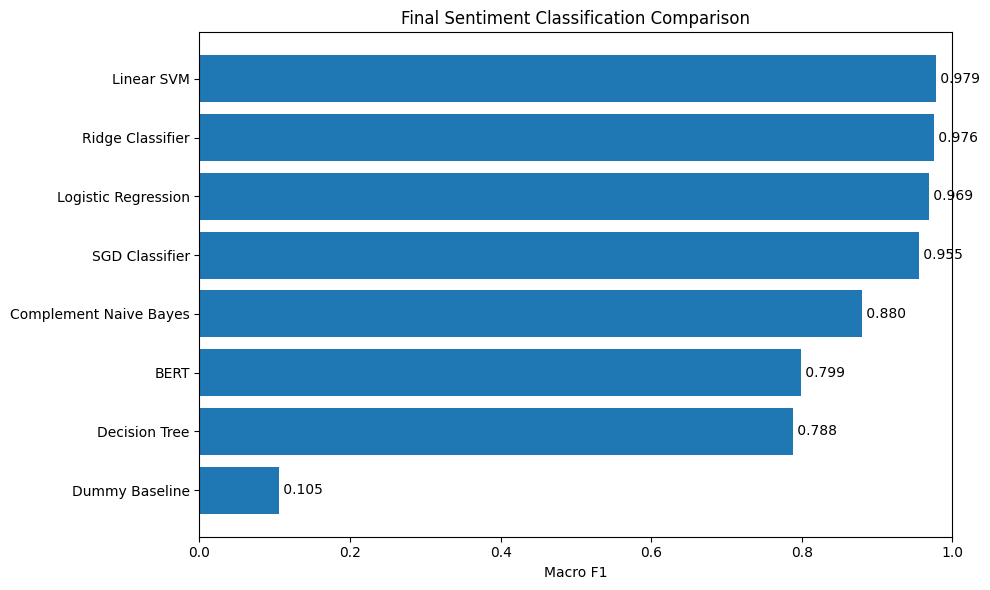

In [33]:
plot_df = final_results.sort_values("Macro F1")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["Model"], plot_df["Macro F1"])
ax.set_title("Final Sentiment Classification Comparison")
ax.set_xlabel("Macro F1")
ax.set_xlim(0, 1)

for i, value in enumerate(plot_df["Macro F1"]):
    ax.text(value, i, f" {value:.3f}", va="center")

plt.tight_layout()
plt.show()